In [1]:
#import libraries

In [2]:
#dataset

In [3]:
#data preprocrssing

In [4]:
#data wrangling

In [5]:
#EDA

In [6]:
#declare x, y
#x_train_test, y_train_test

In [7]:
#Linear Regression

C:\Users\RithikRaj\AppData\Local\Temp\ipykernel_35316\1656884822.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\RithikRaj\AppData\Local\Temp\ipykernel_35316\1656884822.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

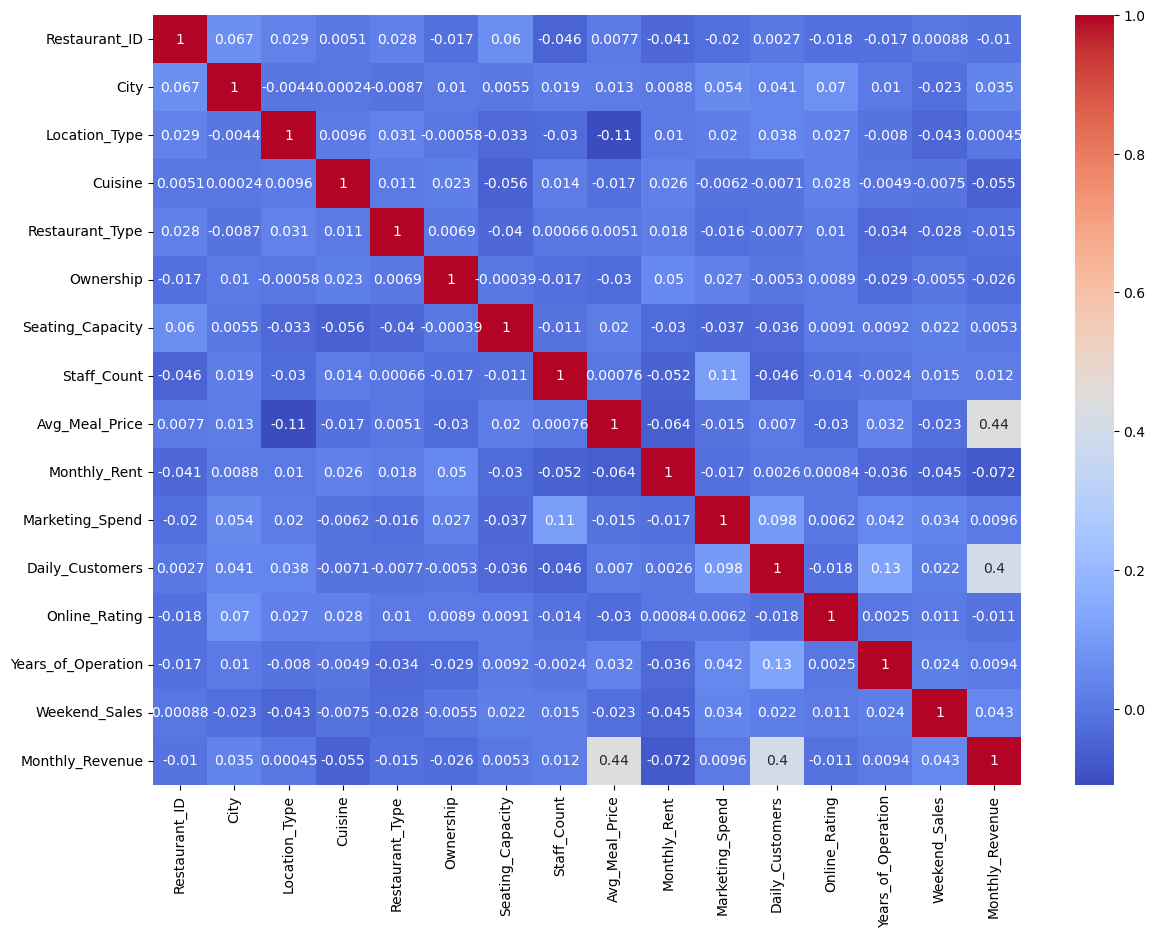


Linear Regression
MAE : 2562413.9039763464
MSE : 19139519162269.574
RMSE : 4374873.616719639
R2 Score : 0.5192116474354179

Feature Importance
               Feature    Coefficient
2        Location_Type  350090.685365
1                 City   94657.804735
12       Online_Rating   41176.362480
11     Daily_Customers    8756.830782
7          Staff_Count    8552.887221
8       Avg_Meal_Price    7918.459566
6     Seating_Capacity    1314.082959
14       Weekend_Sales       1.415581
9         Monthly_Rent      -1.568769
10     Marketing_Spend      -5.324117
0        Restaurant_ID    -478.729095
5            Ownership  -20280.190734
13  Years_of_Operation  -43790.302244
4      Restaurant_Type -239276.698038
3              Cuisine -264917.117522


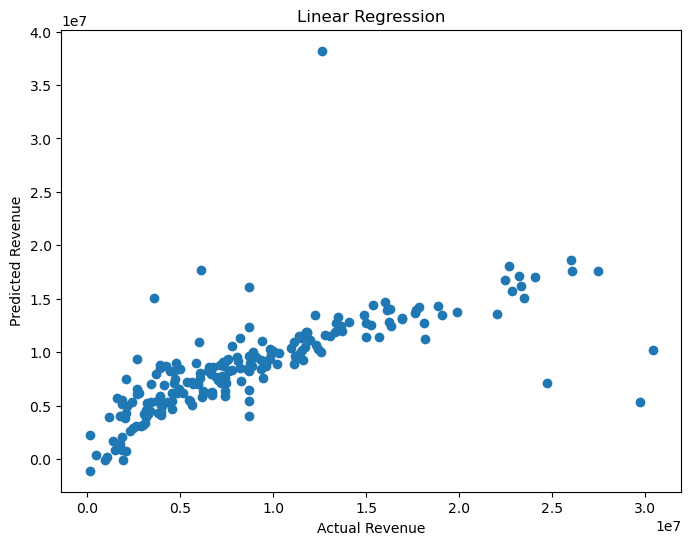


Ridge Regression
MAE : 2562323.3897094512
MSE : 19139059893889.09
RMSE : 4374821.127073551
R2 Score : 0.5192231843442694

Feature Importance
               Feature    Coefficient
2        Location_Type  349424.423120
1                 City   94625.045187
12       Online_Rating   41170.880143
11     Daily_Customers    8756.880020
7          Staff_Count    8551.739149
8       Avg_Meal_Price    7918.326683
6     Seating_Capacity    1314.325195
14       Weekend_Sales       1.415525
9         Monthly_Rent      -1.568842
10     Marketing_Spend      -5.323540
0        Restaurant_ID    -478.702727
5            Ownership  -20215.708750
13  Years_of_Operation  -43789.276212
4      Restaurant_Type -239033.058238
3              Cuisine -264758.782770


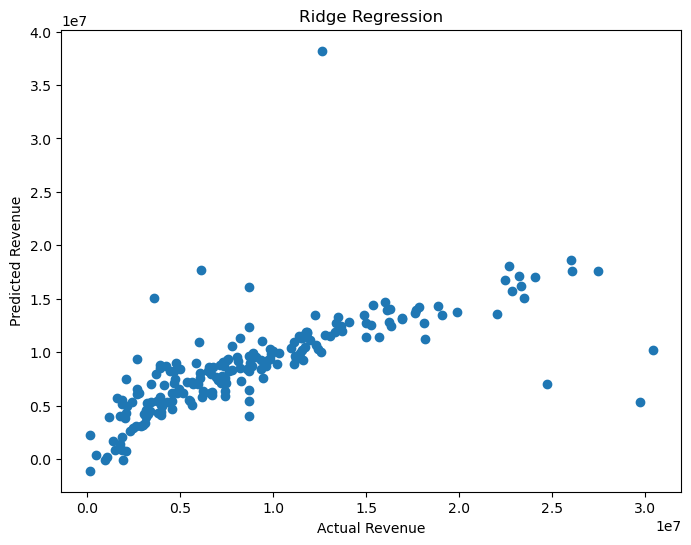


Lasso Regression
MAE : 2562413.888674357
MSE : 19139519068481.125
RMSE : 4374873.60600065
R2 Score : 0.5192116497914017

Feature Importance
               Feature    Coefficient
2        Location_Type  350090.537373
1                 City   94657.771614
12       Online_Rating   41176.345373
11     Daily_Customers    8756.830798
7          Staff_Count    8552.886907
8       Avg_Meal_Price    7918.459558
6     Seating_Capacity    1314.083032
14       Weekend_Sales       1.415581
9         Monthly_Rent      -1.568769
10     Marketing_Spend      -5.324117
0        Restaurant_ID    -478.729095
5            Ownership  -20279.793998
13  Years_of_Operation  -43790.300847
4      Restaurant_Type -239276.617849
3              Cuisine -264917.072286


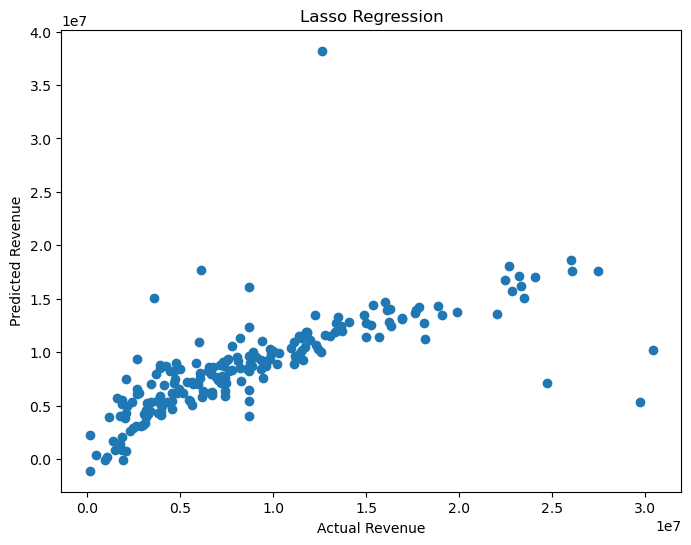


ElasticNet Regression
MAE : 2558896.9019153942
MSE : 19121973632301.234
RMSE : 4372867.895592232
R2 Score : 0.5196523944770145

Feature Importance
               Feature    Coefficient
2        Location_Type  325038.489185
1                 City   93344.114319
12       Online_Rating   40935.695904
11     Daily_Customers    8758.682220
7          Staff_Count    8508.844172
8       Avg_Meal_Price    7913.468838
6     Seating_Capacity    1323.573540
14       Weekend_Sales       1.413513
9         Monthly_Rent      -1.571574
10     Marketing_Spend      -5.301679
0        Restaurant_ID    -477.720518
5            Ownership  -18036.708072
13  Years_of_Operation  -43750.754475
4      Restaurant_Type -229828.457084
3              Cuisine -258670.687151


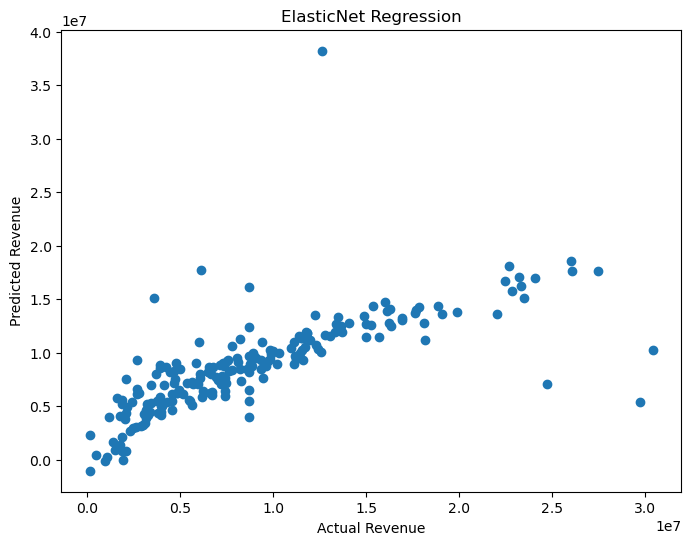


Final Model Comparison
                   Model           MAE           MSE          RMSE  R2 Score
0      Linear Regression  2.562414e+06  1.913952e+13  4.374874e+06  0.519212
1       Ridge Regression  2.562323e+06  1.913906e+13  4.374821e+06  0.519223
2       Lasso Regression  2.562414e+06  1.913952e+13  4.374874e+06  0.519212
3  ElasticNet Regression  2.558897e+06  1.912197e+13  4.372868e+06  0.519652

Best Performing Model
                   Model           MAE           MSE          RMSE  R2 Score
3  ElasticNet Regression  2.558897e+06  1.912197e+13  4.372868e+06  0.519652


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_excel(r"C:\Users\RithikRaj\Downloads\restaurant_revenue_dataset.xlsx")

df = df.drop_duplicates()

num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

X = df.drop("Monthly_Revenue", axis=1)

y = df["Monthly_Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)

    coeff_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    })

    print("\nFeature Importance")
    print(coeff_df.sort_values(by="Coefficient", ascending=False))

    plt.figure(figsize=(8,6))

    plt.scatter(y_test, y_pred)

    plt.xlabel("Actual Revenue")

    plt.ylabel("Predicted Revenue")

    plt.title(name)

    plt.show()

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison")
print(results_df)

best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nBest Performing Model")
print(best_model.head(1))